In [ ]:
import pandas as pd
import sys
from pathlib import Path
import os
from dotenv import load_dotenv

load_dotenv()  # Load environment variables from .env file

data = pd.read_csv("training_data.csv")

data.head()

data.T


,0,1,2,3,4,5,6,7,8,9,...,1353,1354,1355,1356,1357,1358,1359,1360,1361,1362
Unnamed: 0,0,1,2,3,4,5,6,7,8,9,...,1353,1354,1355,1356,1357,1358,1359,1360,1361,1362
tBodyAcc-mean()-X,0.010747,0.002934,0.03138,0.013981,0.137046,-0.026522,0.032513,-0.020925,-0.065287,-0.037061,...,-0.00112,0.002751,0.003857,0.00118,-0.000346,-0.000271,0.000189,-0.000928,-0.002396,-0.002543
tBodyAcc-std()-X,0.106408,0.04835,0.122447,0.241432,0.339028,0.170081,0.176043,0.135373,0.164294,0.158375,...,0.011239,0.013319,0.011961,0.009345,0.016154,0.017143,0.016909,0.005981,0.006867,0.007017
tBodyAcc-min()-X,-0.292632,-0.120507,-0.103824,-0.335487,-0.346681,-0.322769,-0.36188,-0.435736,-0.771936,-0.581592,...,-0.037797,-0.037791,-0.022095,-0.017039,-0.056812,-0.054007,-0.056488,-0.01644,-0.02421,-0.024511
tBodyAcc-max()-X,0.21867,0.171882,0.447113,0.73618,0.727994,0.322341,0.435227,0.699095,0.569085,0.341218,...,0.02436,0.025874,0.034636,0.027089,0.064533,0.067236,0.023484,0.009773,0.019818,0.011021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
fBodyAccMag-energy(),11.010047,2.798263,19.42067,47.422422,74.190604,14.558174,19.344093,16.825153,14.000004,11.941959,...,0.333003,0.198273,0.093663,0.157333,0.163147,0.270989,0.158759,0.025682,0.037887,0.039279
fBodyAccMag-entropy(),0.312211,0.780496,0.672169,0.504128,0.114676,0.342981,0.312211,0.312211,0.42583,0.383447,...,0.42583,0.496701,0.508315,0.383447,0.988041,0.872154,0.753526,0.496701,0.446776,0.114676
fBodyAccMag-meanFreq(),5.475927,6.983243,4.489402,4.389821,4.00086,5.585678,7.202027,6.603968,6.643903,6.569111,...,5.023255,5.242898,4.029442,4.746805,4.324112,4.959056,5.250203,5.181528,5.070185,5.46068
Activity,STANDING,STANDING,STANDING,STANDING,STANDING,STANDING,STANDING,STANDING,STANDING,STANDING,...,STANDING,STANDING,STANDING,STANDING,STANDING,STANDING,STANDING,STANDING,STANDING,STANDING


# Data Visualisation

The dataset contains time-domain and frequency-domain statistical features extracted from accelerometer and gyroscope readings (mean, std, min, max, energy, entropy, meanFreq across X/Y/Z axes). Each row is one **~2.5-second sliding window**, labelled with a physical **Activity**.

A 2.5-second window is long enough to capture roughly 2–3 full walking strides at a typical cadence (~120 steps/min), which is why stride-periodic features (energy, std, frequency statistics) are highly informative as classifier inputs.

The cells below explore:
1. Class distribution
2. Key feature distributions per activity (boxplots)
3. 2-D scatter of mean acceleration axes coloured by activity
4. PCA projection of the full feature space
5. Correlation heatmap of the most variable features
6. Feature importance (ANOVA F-score)
7. Frequency-domain spectral profiles (wave charts)
8. Frequency energy heatmap
9. Time-domain timelines
10. Violin plots of top discriminative features

In [36]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Separate features from metadata
feature_cols = [c for c in data.columns if c not in ("Activity", "timestamp")]
X = data[feature_cols].astype(float)
y = data["Activity"]

activities = y.unique()
n_activities = len(activities)

# Consistent colour palette across all plots
palette = cm.get_cmap("tab10", n_activities)
color_map = {act: palette(i) for i, act in enumerate(sorted(activities))}

print(f"Samples: {len(data)}   Features: {len(feature_cols)}   Activities: {sorted(activities)}")

Samples: 1363   Features: 180   Activities: ['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS', 'WALKING_UPSTAIRS']


/tmp/ipykernel_330926/1136892823.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = cm.get_cmap("tab10", n_activities)


## 1 — Class Distribution

How many labelled windows exist for each activity? Imbalanced classes can bias a classifier towards the majority label.

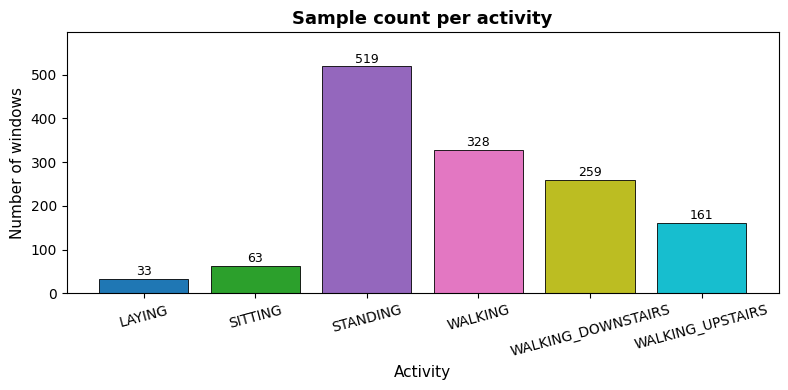

In [37]:
counts = y.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(counts.index, counts.values,
              color=[color_map[a] for a in counts.index], edgecolor="black", linewidth=0.6)

# Annotate bar heights
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
            str(val), ha="center", va="bottom", fontsize=9)

ax.set_title("Sample count per activity", fontsize=13, fontweight="bold")
ax.set_xlabel("Activity", fontsize=11)
ax.set_ylabel("Number of windows", fontsize=11)
ax.tick_params(axis="x", rotation=15)
ax.set_ylim(0, counts.max() * 1.15)
plt.tight_layout()
plt.show()

**Interpretation:** With six classes and ~1,363 total windows, the dataset is reasonably balanced if each activity contributes roughly 200–250 windows. Any class with noticeably fewer samples will be under-represented during training, making the model less reliable for that activity. Since each window spans **~2.5 seconds**, the total recorded time per activity is approximately `count × 2.5 s` — a useful sanity check that the recording protocol was consistent. Heavy imbalance would warrant oversampling (SMOTE) or class-weighted loss during model training.

## 2 — Feature Distributions per Activity (Boxplots)

Boxplots of six informative features: mean and std of body-acceleration on all three axes. The box spans the inter-quartile range (IQR), the line inside is the median, and whiskers extend to 1.5×IQR. Wide separation between activities indicates a feature is discriminative.

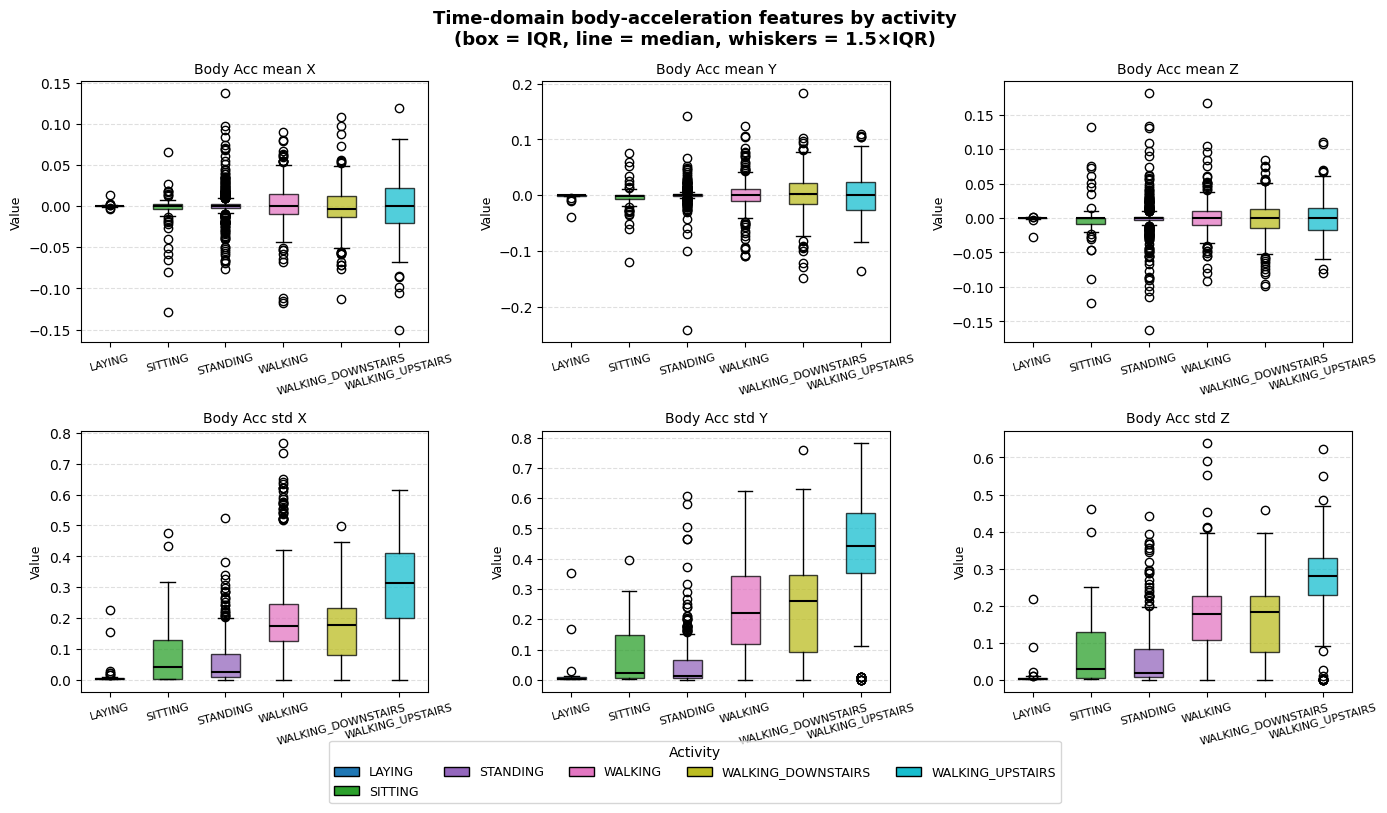

In [38]:
features_to_plot = [
    ("tBodyAcc-mean()-X", "Body Acc mean X"),
    ("tBodyAcc-mean()-Y", "Body Acc mean Y"),
    ("tBodyAcc-mean()-Z", "Body Acc mean Z"),
    ("tBodyAcc-std()-X",  "Body Acc std X"),
    ("tBodyAcc-std()-Y",  "Body Acc std Y"),
    ("tBodyAcc-std()-Z",  "Body Acc std Z"),
]

sorted_acts = sorted(activities)
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle("Time-domain body-acceleration features by activity\n"
             "(box = IQR, line = median, whiskers = 1.5×IQR)", fontsize=13, fontweight="bold")

for ax, (col, label) in zip(axes.flat, features_to_plot):
    groups = [data.loc[y == act, col].astype(float).values for act in sorted_acts]
    bp = ax.boxplot(groups, patch_artist=True, notch=False,
                    medianprops=dict(color="black", linewidth=1.5))
    for patch, act in zip(bp["boxes"], sorted_acts):
        patch.set_facecolor(color_map[act])
        patch.set_alpha(0.75)
    ax.set_title(label, fontsize=10)
    ax.set_xticks(range(1, len(sorted_acts) + 1))
    ax.set_xticklabels(sorted_acts, rotation=15, fontsize=8)
    ax.set_ylabel("Value", fontsize=9)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

# Shared legend
from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=color_map[a], edgecolor="black", label=a) for a in sorted_acts]
fig.legend(handles=legend_handles, title="Activity", loc="lower center",
           ncol=min(n_activities, 5), bbox_to_anchor=(0.5, -0.02), fontsize=9)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

**Interpretation:** The clearest separation is on the **std** features: walking activities show a wide spread (large std of acceleration), while static activities (LAYING, SITTING, STANDING) are tightly clustered near zero. On the **mean** features, the Z-axis separates LAYING from upright postures because gravity dominates the Z component when the phone lies flat. The wide IQR boxes for walking activities reflect natural gait variability within each ~2.5-second window — steps are not perfectly uniform. Features where the boxes of different activities do not overlap at all (e.g. std-X for WALKING vs LAYING) are the strongest single-feature classifiers.

## 3 — 2-D Scatter: Mean Acceleration Axes

Plotting the three body-acceleration mean values pairwise reveals how activities cluster in raw feature space before any dimensionality reduction.

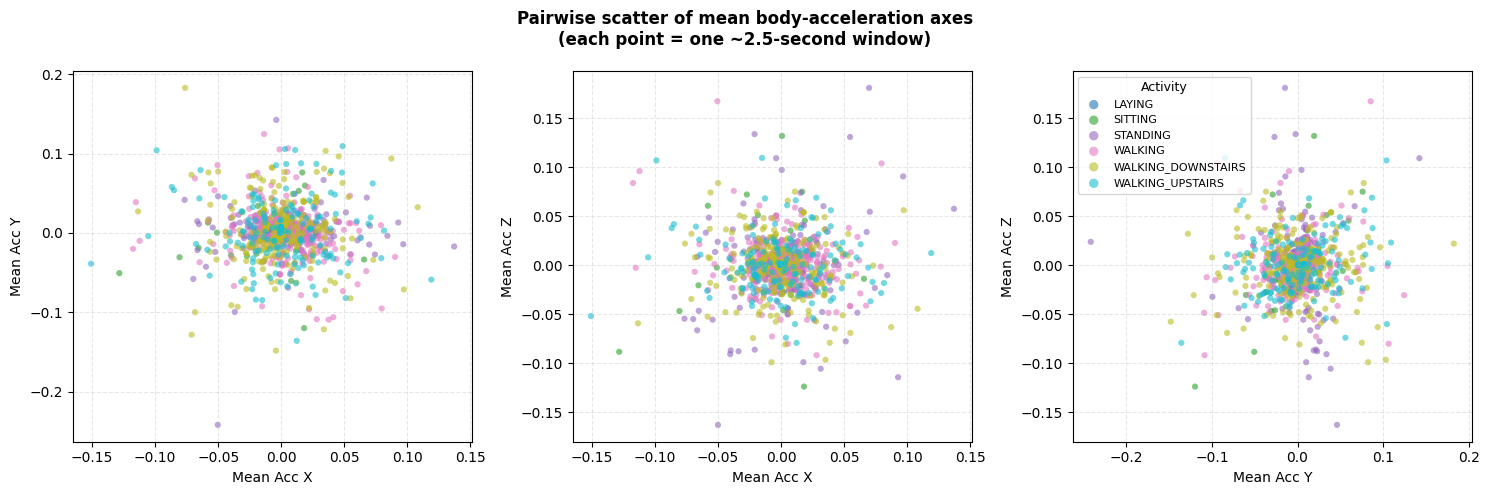

In [39]:
pairs = [
    ("tBodyAcc-mean()-X", "tBodyAcc-mean()-Y", "Mean Acc X", "Mean Acc Y"),
    ("tBodyAcc-mean()-X", "tBodyAcc-mean()-Z", "Mean Acc X", "Mean Acc Z"),
    ("tBodyAcc-mean()-Y", "tBodyAcc-mean()-Z", "Mean Acc Y", "Mean Acc Z"),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Pairwise scatter of mean body-acceleration axes\n(each point = one ~2.5-second window)",
             fontsize=12, fontweight="bold")

for ax, (cx, cy, lx, ly) in zip(axes, pairs):
    for act in sorted_acts:
        mask = y == act
        ax.scatter(data.loc[mask, cx].astype(float),
                   data.loc[mask, cy].astype(float),
                   c=[color_map[act]], label=act, alpha=0.6, s=20, edgecolors="none")
    ax.set_xlabel(lx, fontsize=10)
    ax.set_ylabel(ly, fontsize=10)
    ax.grid(linestyle="--", alpha=0.3)

# One shared legend on the last axes
axes[-1].legend(title="Activity", fontsize=8, title_fontsize=9,
                loc="best", markerscale=1.5)
plt.tight_layout()
plt.show()

**Interpretation:** A tight, well-separated cluster per activity in any of these pairwise projections means those two features alone could nearly classify that activity. LAYING typically forms an isolated cluster shifted along the Z-axis (gravity effect). The three walking variants often overlap each other in mean-acceleration space because their average acceleration over a 2.5-second window is similar — the *variability* (std, energy) is what separates them, not the mean. Points that fall far from their cluster's centre represent transition windows where the subject was changing activity mid-window.

## 4 — PCA Projection (Full Feature Space → 2-D)

Principal Component Analysis compresses all 180 features into two orthogonal axes that capture the most variance. Well-separated clusters indicate the features carry enough signal to distinguish activities — which is encouraging for model training.

The explained-variance ratio in the axis labels shows how much of the total variance each component captures.

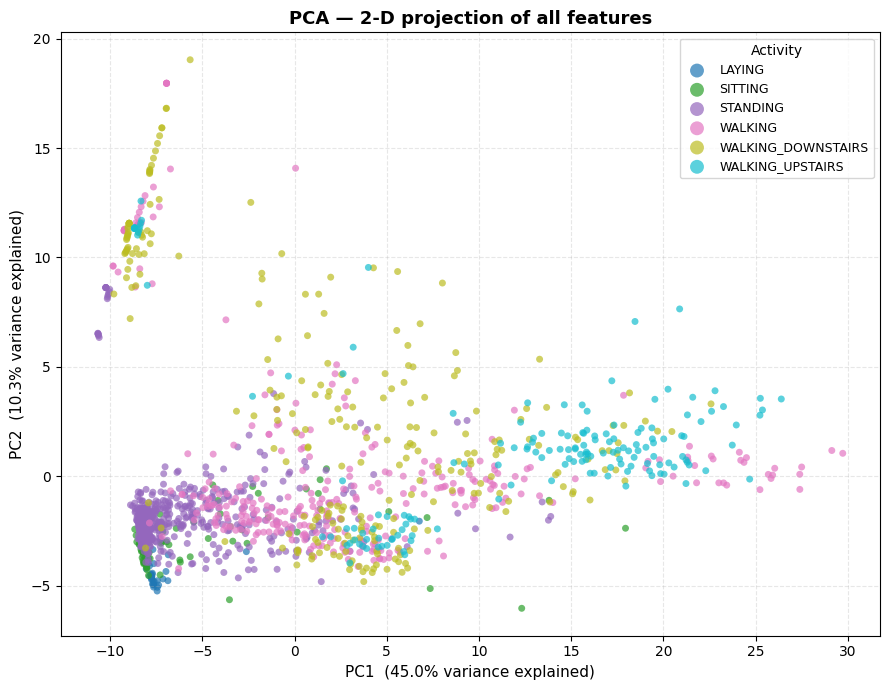

Total variance captured by PC1+PC2: 55.3%


In [40]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
ev = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(9, 7))
for act in sorted_acts:
    mask = (y == act).values
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=[color_map[act]], label=act, alpha=0.7, s=25, edgecolors="none")

ax.set_title("PCA — 2-D projection of all features", fontsize=13, fontweight="bold")
ax.set_xlabel(f"PC1  ({ev[0]*100:.1f}% variance explained)", fontsize=11)
ax.set_ylabel(f"PC2  ({ev[1]*100:.1f}% variance explained)", fontsize=11)
ax.legend(title="Activity", fontsize=9, title_fontsize=10, markerscale=2)
ax.grid(linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Total variance captured by PC1+PC2: {sum(ev)*100:.1f}%")

**Interpretation:** If the two principal components together explain a high fraction of variance (e.g. >60%), then the 180-feature space has a strong low-dimensional structure — good news for linear classifiers and for interpretability. Well-separated clusters in this 2-D view confirm that the features carry genuine class signal (not just noise). Overlapping clusters (common between SITTING and STANDING) indicate pairs of activities that are inherently hard to distinguish from motion alone — they may require additional context or more nuanced features. The 2.5-second window length is important here: a shorter window would produce noisier per-window statistics, making clusters less tight.

## 5 — Correlation Heatmap (Top Variable Features)

High pairwise correlation means two features carry nearly identical information. The heatmap below focuses on the 20 features with the highest variance — the ones most likely to be discriminative — and shows which are redundant (dark red ≈ +1, dark blue ≈ −1).

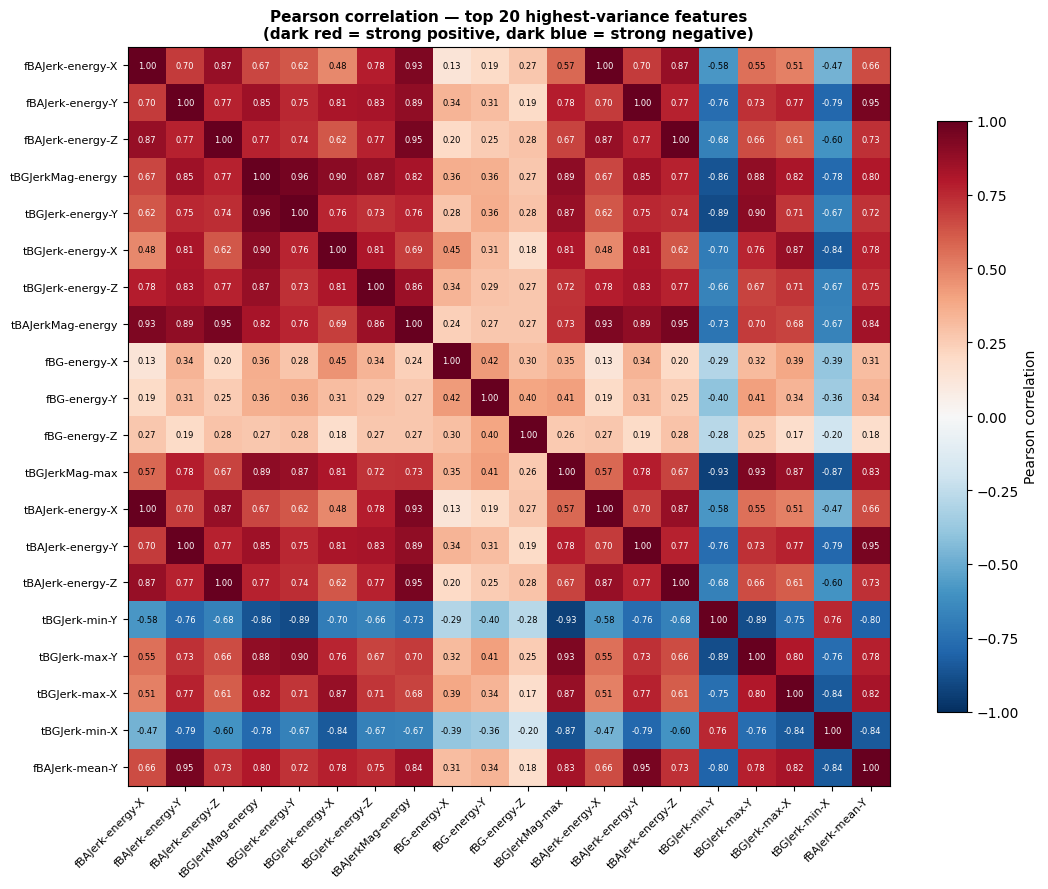

In [41]:
TOP_N = 20
top_var_cols = X.var().nlargest(TOP_N).index.tolist()
corr = X[top_var_cols].corr()

# Shorten labels for readability
short_labels = [c.replace("tBody", "tB").replace("fBody", "fB")
                 .replace("Acc", "A").replace("Gyro", "G")
                 .replace("()-", "-").replace("()", "") for c in top_var_cols]

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap="RdBu_r", aspect="auto")

cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("Pearson correlation", fontsize=10)

ax.set_xticks(range(TOP_N))
ax.set_yticks(range(TOP_N))
ax.set_xticklabels(short_labels, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(short_labels, fontsize=8)

# Annotate cells
for i in range(TOP_N):
    for j in range(TOP_N):
        val = corr.values[i, j]
        text_color = "white" if abs(val) > 0.6 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=6, color=text_color)

ax.set_title(f"Pearson correlation — top {TOP_N} highest-variance features\n"
             "(dark red = strong positive, dark blue = strong negative)", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

**Interpretation:** Strongly correlated feature pairs (|r| > 0.9, deep red or blue) are largely redundant — keeping both provides almost no additional information to a model. For example, energy and std of the same axis are structurally related (energy ∝ mean² + std²), so they often appear as a correlated cluster. Dimensionality reduction (PCA) or feature selection can safely collapse these groups without hurting accuracy. Negatively correlated pairs (dark blue) suggest complementary signals that together define the activity boundary more precisely than either alone. Features that are uncorrelated with everything else carry unique information and are particularly valuable to keep.

## 6 — Feature Importance (ANOVA F-Score)

ANOVA F-score measures how much a feature's mean differs *across* activities relative to how much it varies *within* each activity. A high score means the feature is tightly grouped per class and well-separated between classes — i.e. it is highly discriminative. This directly shows what a classifier will rely on most.

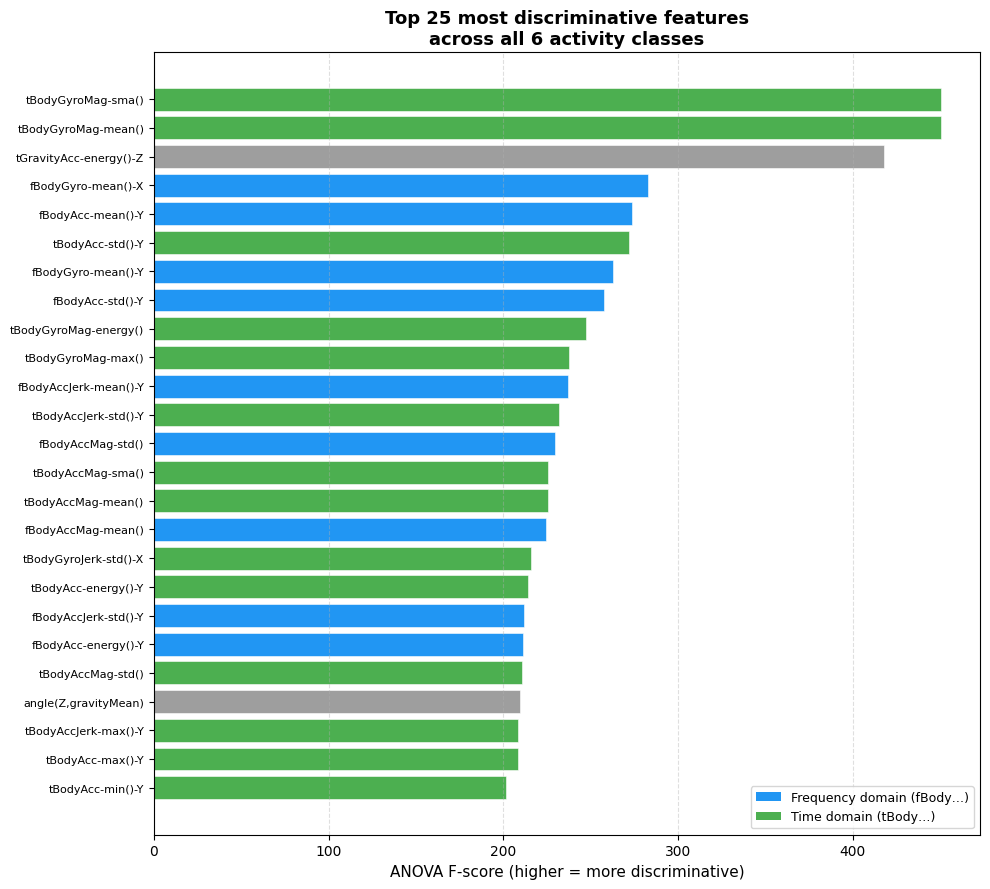

Top 10 features:
tBodyGyroMag-sma()        450.334312
tBodyGyroMag-mean()       450.334312
tGravityAcc-energy()-Z    417.922749
fBodyGyro-mean()-X        282.858157
fBodyAcc-mean()-Y         273.672546
tBodyAcc-std()-Y          271.928642
fBodyGyro-mean()-Y        262.521601
fBodyAcc-std()-Y          257.700100
tBodyGyroMag-energy()     247.495133
tBodyGyroMag-max()        237.551860


In [42]:
from sklearn.feature_selection import f_classif

f_scores, _ = f_classif(X_scaled, y)
importance = pd.Series(f_scores, index=feature_cols).sort_values(ascending=False)

TOP = 25
top_feats = importance.head(TOP)

# Colour bars by sensor domain
def domain_color(name):
    if name.startswith("fBody"):   return "#2196F3"   # blue  = frequency domain
    if name.startswith("tBody"):   return "#4CAF50"   # green = time domain
    return "#9E9E9E"

bar_colors = [domain_color(n) for n in top_feats.index]

fig, ax = plt.subplots(figsize=(10, 9))
bars = ax.barh(top_feats.index[::-1], top_feats.values[::-1],
               color=bar_colors[::-1], edgecolor="white", linewidth=0.4)

ax.set_xlabel("ANOVA F-score (higher = more discriminative)", fontsize=11)
ax.set_title(f"Top {TOP} most discriminative features\nacross all 6 activity classes", fontsize=13, fontweight="bold")
ax.grid(axis="x", linestyle="--", alpha=0.4)
ax.tick_params(axis="y", labelsize=8)

from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor="#2196F3", label="Frequency domain (fBody…)"),
    Patch(facecolor="#4CAF50", label="Time domain (tBody…)"),
]
ax.legend(handles=legend_handles, loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

print("Top 10 features:")
print(importance.head(10).to_string())

**Interpretation:** The features with the highest F-scores are the ones a model will lean on most. Energy and standard deviation features tend to dominate because **static activities** (LAYING, SITTING, STANDING) produce very little acceleration variance, while **dynamic activities** (WALKING, WALKING_UPSTAIRS/DOWNSTAIRS) produce strong, rhythmic oscillations. Features from the frequency domain (blue) often rank highly because the FFT naturally separates periodic motion from noise. If many top features come from the same sensor axis (e.g. Z-axis), it suggests that axis captures the most activity-specific signal.

## 7 — Frequency-Domain Spectral Profiles (Wave Charts)

Each 2.5-second window has been summarised by five frequency statistics — **mean amplitude, std, energy, entropy, and mean frequency** — computed after applying an FFT to the raw sensor signal. Plotting these statistics in order (from broadband descriptors → spectral shape descriptors) gives a *spectral fingerprint* for each activity.

A **flat, low profile** means the signal is quiet (static posture). A **peaked, high-energy profile** means rhythmic, high-power motion (walking). **High entropy** means spectrally noisy / unpredictable motion (e.g. stairs with irregular cadence).

Three sensors are shown: accelerometer (Acc), gyroscope (Gyro), and linear jerk (AccJerk).

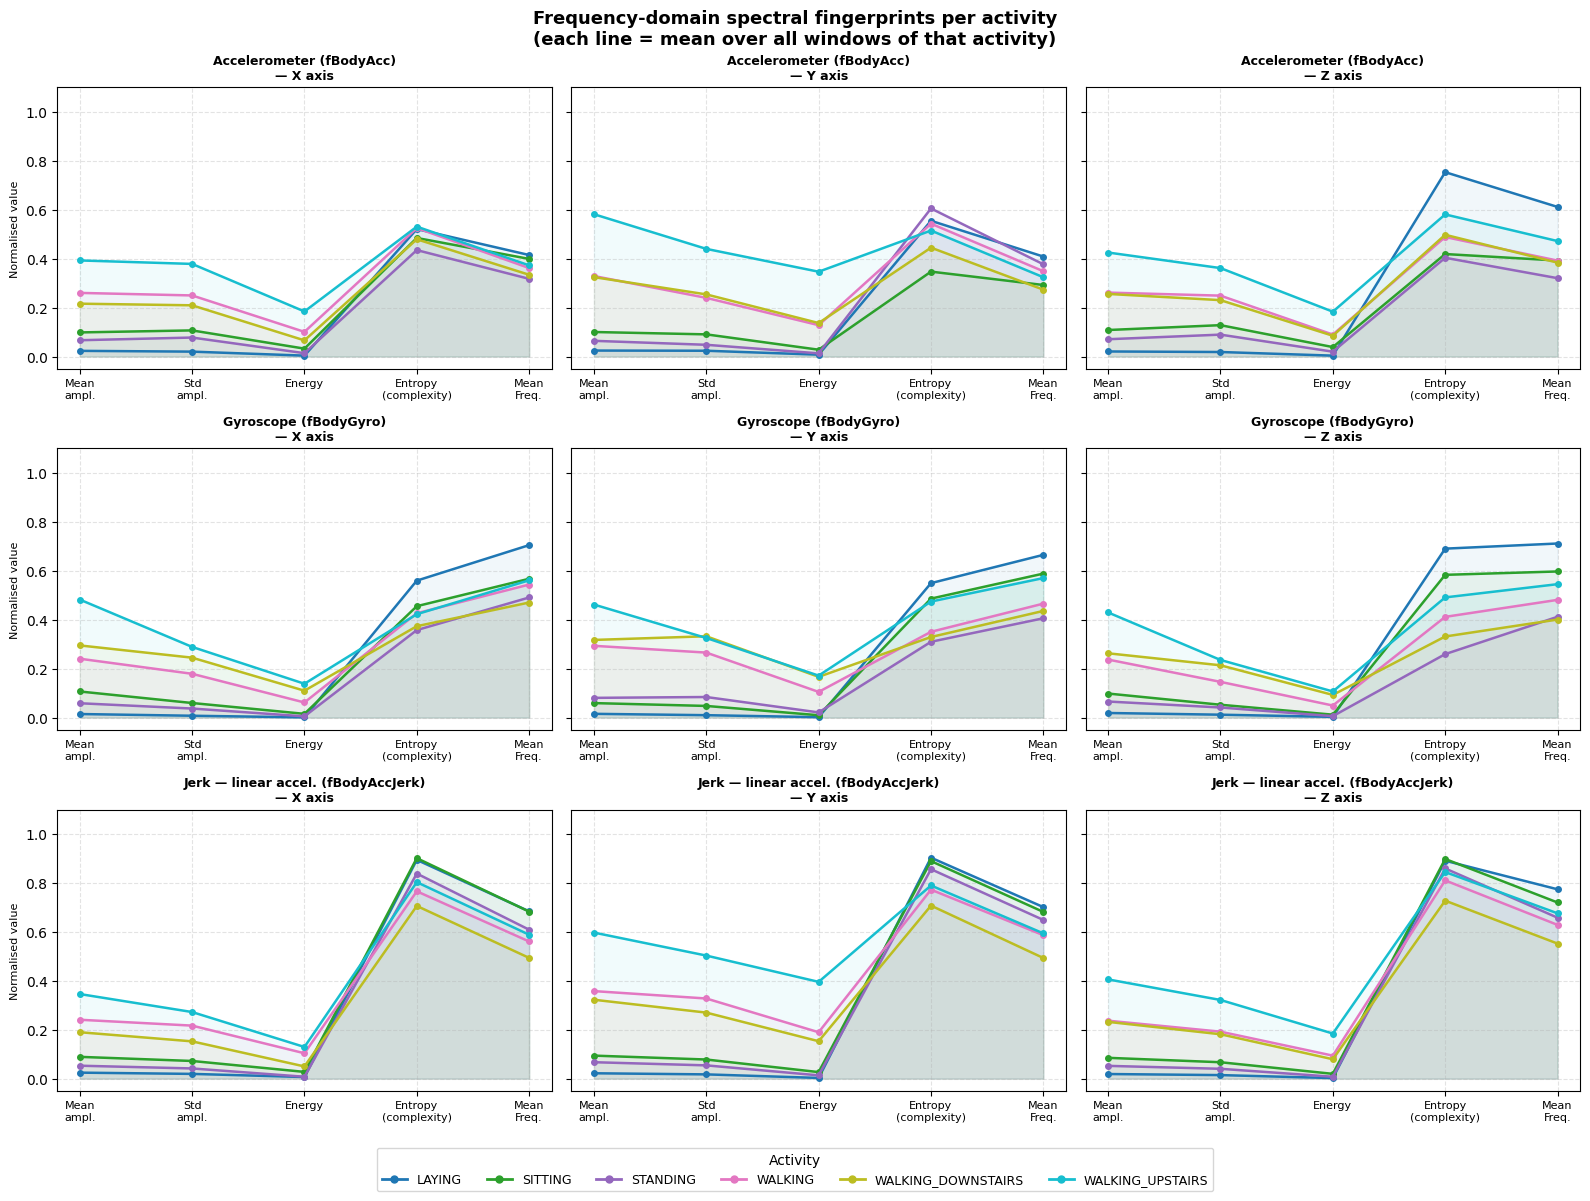

In [43]:
from matplotlib.lines import Line2D

# Five spectral statistics in a meaningful order
STAT_NAMES  = ["mean",     "std",     "energy",    "entropy",   "meanFreq"]
STAT_LABELS = ["Mean\nampl.", "Std\nampl.", "Energy", "Entropy\n(complexity)", "Mean\nFreq."]

sensors = [
    ("fBodyAcc",     "Accelerometer (fBodyAcc)"),
    ("fBodyGyro",    "Gyroscope (fBodyGyro)"),
    ("fBodyAccJerk", "Jerk — linear accel. (fBodyAccJerk)"),
]
axes_xyz = ["X", "Y", "Z"]

fig, big_axes = plt.subplots(len(sensors), 3, figsize=(16, 12), sharey="row")
fig.suptitle("Frequency-domain spectral fingerprints per activity\n"
             "(each line = mean over all windows of that activity)",
             fontsize=13, fontweight="bold")

for row, (sensor_prefix, sensor_label) in enumerate(sensors):
    for col, axis in enumerate(axes_xyz):
        ax = big_axes[row][col]
        cols_ordered = []
        for stat in STAT_NAMES:
            if stat in ("mean", "std", "energy", "entropy"):
                col_name = f"{sensor_prefix}-{stat}()-{axis}"
            else:  # meanFreq
                col_name = f"{sensor_prefix}-{stat}()-{axis}"
            cols_ordered.append(col_name)

        # Normalise each statistic across activities to [0,1] so different units are comparable
        stat_data = data[cols_ordered + ["Activity"]].copy()
        for c in cols_ordered:
            stat_data[c] = stat_data[c].astype(float)
            mn, mx = stat_data[c].min(), stat_data[c].max()
            if mx > mn:
                stat_data[c] = (stat_data[c] - mn) / (mx - mn)

        for act in sorted_acts:
            profile = stat_data.loc[stat_data["Activity"] == act, cols_ordered].mean().values
            ax.plot(range(len(STAT_NAMES)), profile,
                    marker="o", markersize=4, linewidth=1.8,
                    color=color_map[act], label=act)
            ax.fill_between(range(len(STAT_NAMES)), profile, alpha=0.06, color=color_map[act])

        ax.set_xticks(range(len(STAT_NAMES)))
        ax.set_xticklabels(STAT_LABELS, fontsize=8)
        ax.set_ylim(-0.05, 1.1)
        ax.set_ylabel("Normalised value", fontsize=8) if col == 0 else None
        ax.set_title(f"{sensor_label}\n— {axis} axis", fontsize=9, fontweight="bold")
        ax.grid(linestyle="--", alpha=0.35)

# Shared legend
legend_lines = [Line2D([0], [0], color=color_map[a], linewidth=2, marker="o", markersize=5, label=a)
                for a in sorted_acts]
fig.legend(handles=legend_lines, title="Activity", loc="lower center",
           ncol=len(sorted_acts), bbox_to_anchor=(0.5, -0.01), fontsize=9)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

**Interpretation:** The three walking activities (WALKING, WALKING_UPSTAIRS, WALKING_DOWNSTAIRS) share a similar elevated profile shape — high energy and std — but can be distinguished by their **mean frequency** and **entropy**. Walking downstairs tends to produce higher-entropy, more irregular jerk signals on the Z-axis because foot impact is less symmetric than level walking. Static activities (LAYING, SITTING, STANDING) cluster near zero across all statistics, meaning the FFT detects almost no rhythmic content — their profiles are nearly flat. The gyroscope rows reveal rotational motion: STANDING shows slightly elevated entropy from micro-balance corrections, while WALKING shows a strong, regular gyro oscillation (the hip/torso rotation with each step).

## 8 — Frequency Energy Heatmap by Activity & Signal

How much total spectral energy does each activity produce across the four frequency-domain signals (Acc, Gyro, AccJerk) and their three axes? A heatmap makes it easy to spot which activity–signal combinations carry the most power.

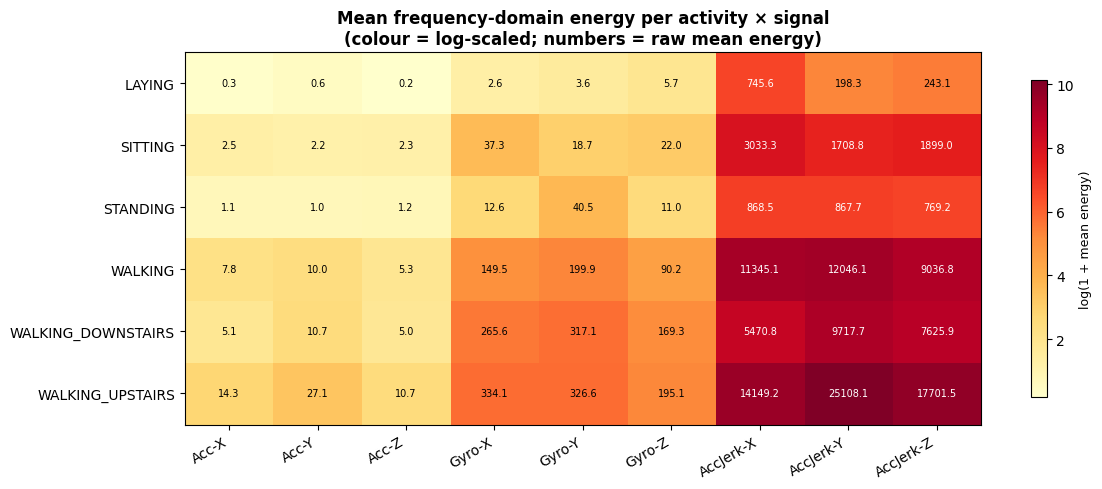

In [44]:
energy_signals = [
    ("fBodyAcc-energy()-X",     "Acc-X"),
    ("fBodyAcc-energy()-Y",     "Acc-Y"),
    ("fBodyAcc-energy()-Z",     "Acc-Z"),
    ("fBodyGyro-energy()-X",    "Gyro-X"),
    ("fBodyGyro-energy()-Y",    "Gyro-Y"),
    ("fBodyGyro-energy()-Z",    "Gyro-Z"),
    ("fBodyAccJerk-energy()-X", "AccJerk-X"),
    ("fBodyAccJerk-energy()-Y", "AccJerk-Y"),
    ("fBodyAccJerk-energy()-Z", "AccJerk-Z"),
]
col_names  = [c for c, _ in energy_signals]
col_labels = [l for _, l in energy_signals]

# Mean energy per activity for each signal
hmap = data.groupby("Activity")[col_names].mean().reindex(sorted_acts)

# Log-scale to handle the large dynamic range (energy spans several orders of magnitude)
import numpy as np
hmap_log = np.log1p(hmap.values)

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(hmap_log, cmap="YlOrRd", aspect="auto")

cbar = fig.colorbar(im, ax=ax, shrink=0.85)
cbar.set_label("log(1 + mean energy)", fontsize=9)

ax.set_xticks(range(len(col_labels)))
ax.set_xticklabels(col_labels, rotation=30, ha="right", fontsize=10)
ax.set_yticks(range(len(sorted_acts)))
ax.set_yticklabels(sorted_acts, fontsize=10)

# Annotate with raw mean values for readability
for i, act in enumerate(sorted_acts):
    for j, col in enumerate(col_names):
        raw_val = hmap.values[i, j]
        ax.text(j, i, f"{raw_val:.1f}", ha="center", va="center",
                fontsize=7, color="black" if hmap_log[i, j] < hmap_log.max() * 0.6 else "white")

ax.set_title("Mean frequency-domain energy per activity × signal\n(colour = log-scaled; numbers = raw mean energy)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

**Interpretation:** The walking activities form a visibly **hot row** across all signals — especially in AccJerk (the rate of change of acceleration), which captures the sharp foot-impact impulse with every step. LAYING produces the most energy on the **Acc-Z axis** because gravity pulls the phone flat against the body, creating a constant DC offset. SITTING and STANDING are nearly cold everywhere except for small gyroscope fluctuations from postural sway. The log scale is necessary because walking energy can be 100× higher than standing energy — raw values would wash out the static-activity differences entirely.

## 9 — Time-Domain Timelines

The timestamp column records *when* each window was captured. Plotting time-domain features chronologically shows how the sensor signal evolves as the subject moves through different activities — and whether features are stable within an activity or drift over time.

Four features are shown: mean and energy of body-acceleration on the X and Z axes.

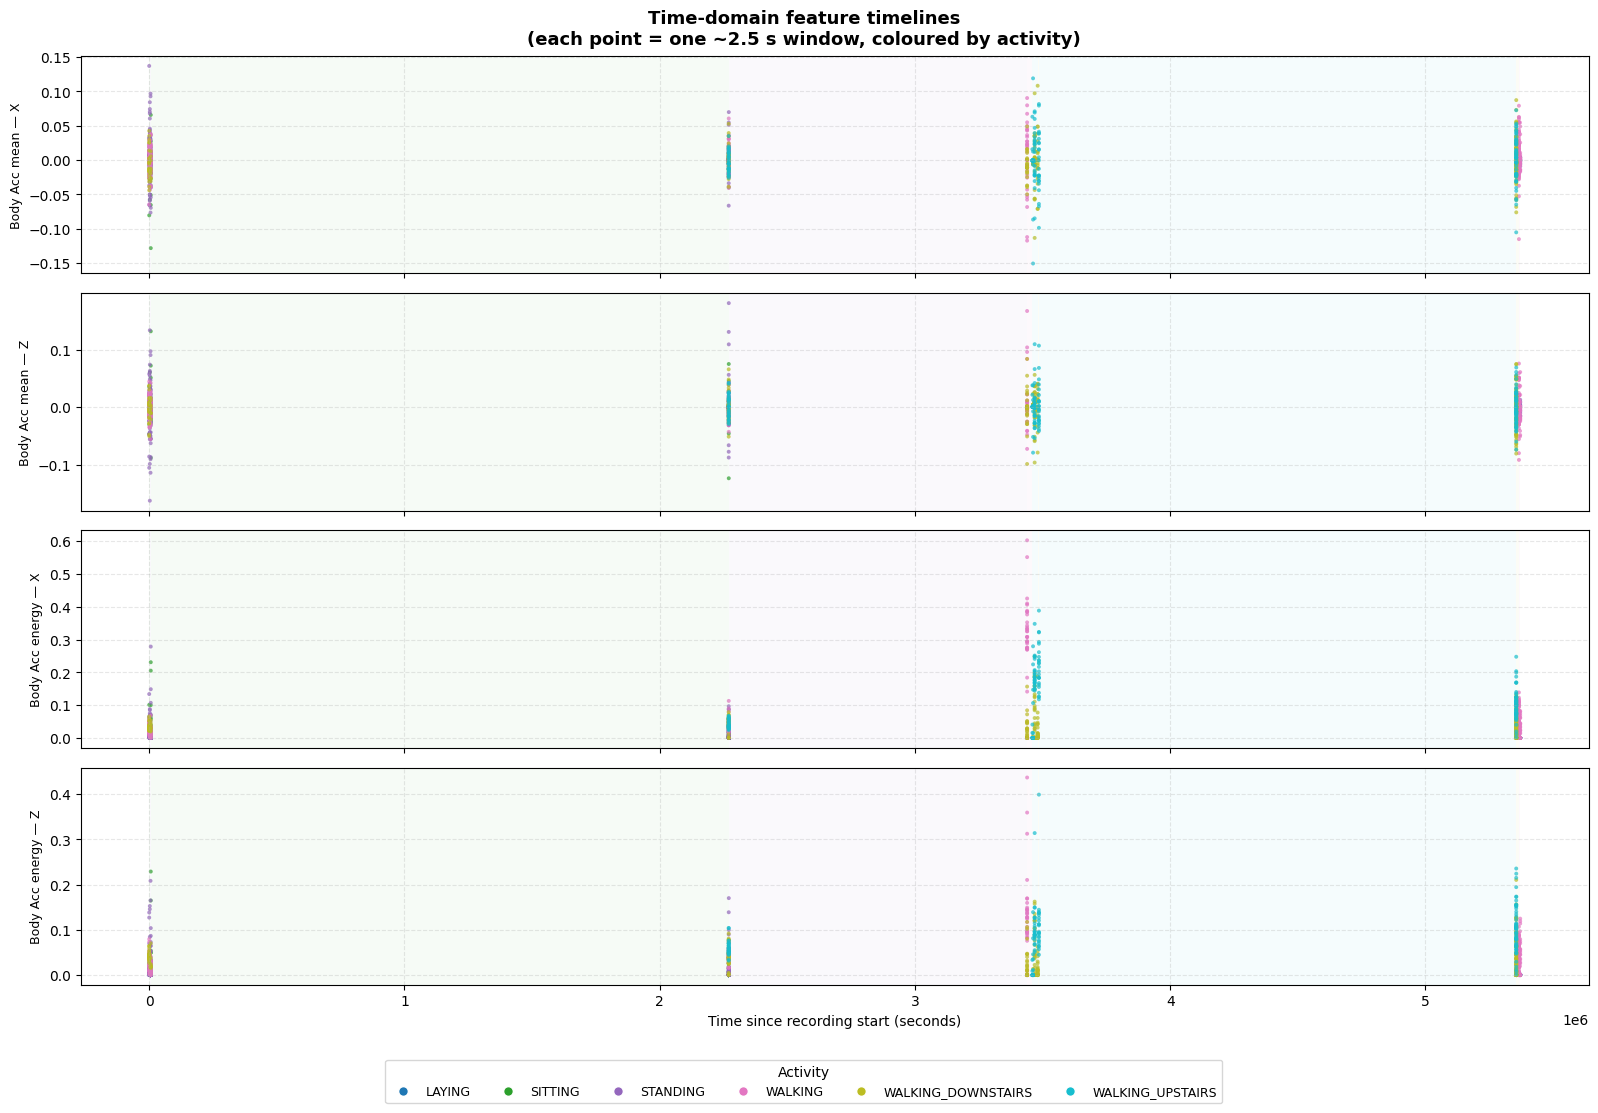

In [45]:
df_time = data.copy()
df_time["timestamp"] = pd.to_numeric(df_time["timestamp"])
df_time = df_time.sort_values("timestamp").reset_index(drop=True)

# Convert ms epoch to seconds relative to start for a readable x-axis
t0 = df_time["timestamp"].iloc[0]
df_time["t_sec"] = (df_time["timestamp"] - t0) / 1000.0

timeline_feats = [
    ("tBodyAcc-mean()-X",   "Body Acc mean — X"),
    ("tBodyAcc-mean()-Z",   "Body Acc mean — Z"),
    ("tBodyAcc-energy()-X", "Body Acc energy — X"),
    ("tBodyAcc-energy()-Z", "Body Acc energy — Z"),
]

fig, axes = plt.subplots(len(timeline_feats), 1, figsize=(16, 11), sharex=True)
fig.suptitle("Time-domain feature timelines\n(each point = one ~2.5 s window, coloured by activity)",
             fontsize=13, fontweight="bold")

for ax, (col, label) in zip(axes, timeline_feats):
    for act in sorted_acts:
        mask = df_time["Activity"] == act
        ax.scatter(df_time.loc[mask, "t_sec"],
                   df_time.loc[mask, col].astype(float),
                   c=[color_map[act]], s=8, alpha=0.7, label=act, edgecolors="none")
    ax.set_ylabel(label, fontsize=9)
    ax.grid(linestyle="--", alpha=0.3)

    # Shade activity regions along the x-axis
    prev_act, prev_t = None, df_time["t_sec"].iloc[0]
    for _, row in df_time.iterrows():
        if row["Activity"] != prev_act:
            if prev_act is not None:
                ax.axvspan(prev_t, row["t_sec"], alpha=0.04,
                           color=color_map[prev_act], linewidth=0)
            prev_act = row["Activity"]
            prev_t = row["t_sec"]
    ax.axvspan(prev_t, df_time["t_sec"].iloc[-1], alpha=0.04,
               color=color_map[prev_act], linewidth=0)

axes[-1].set_xlabel("Time since recording start (seconds)", fontsize=10)

legend_handles = [Line2D([0], [0], marker="o", color="w", markerfacecolor=color_map[a],
                         markersize=7, label=a) for a in sorted_acts]
fig.legend(handles=legend_handles, title="Activity", loc="lower center",
           ncol=len(sorted_acts), bbox_to_anchor=(0.5, -0.02), fontsize=9)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

**Interpretation:** The timelines immediately reveal the **recording protocol**: blocks of the same activity are captured together, producing clean colour bands. Within a static activity (LAYING, SITTING, STANDING) the points cluster tightly into horizontal bands — the feature value barely changes from window to window because there is no motion. Within walking activities the scatter is much wider and noisier, reflecting the natural variability of human gait (stride length changes, momentary pauses, direction changes). Energy on the X-axis spikes sharply when walking begins and drops back to near-zero at rest. The Z-axis mean shifts between LAYING (gravity mostly in Z) and upright postures (gravity in Y), which is why Z-mean is one of the top ANOVA features for separating static postures from each other.

## 10 — Violin Plots of Top Discriminative Features

Violin plots combine a boxplot (median, IQR) with a kernel density estimate of the full distribution. For the six highest-ranked ANOVA features this shows not just *where* the medians sit but *the shape* of each class's distribution — revealing skewness, multi-modality, and how cleanly classes separate.

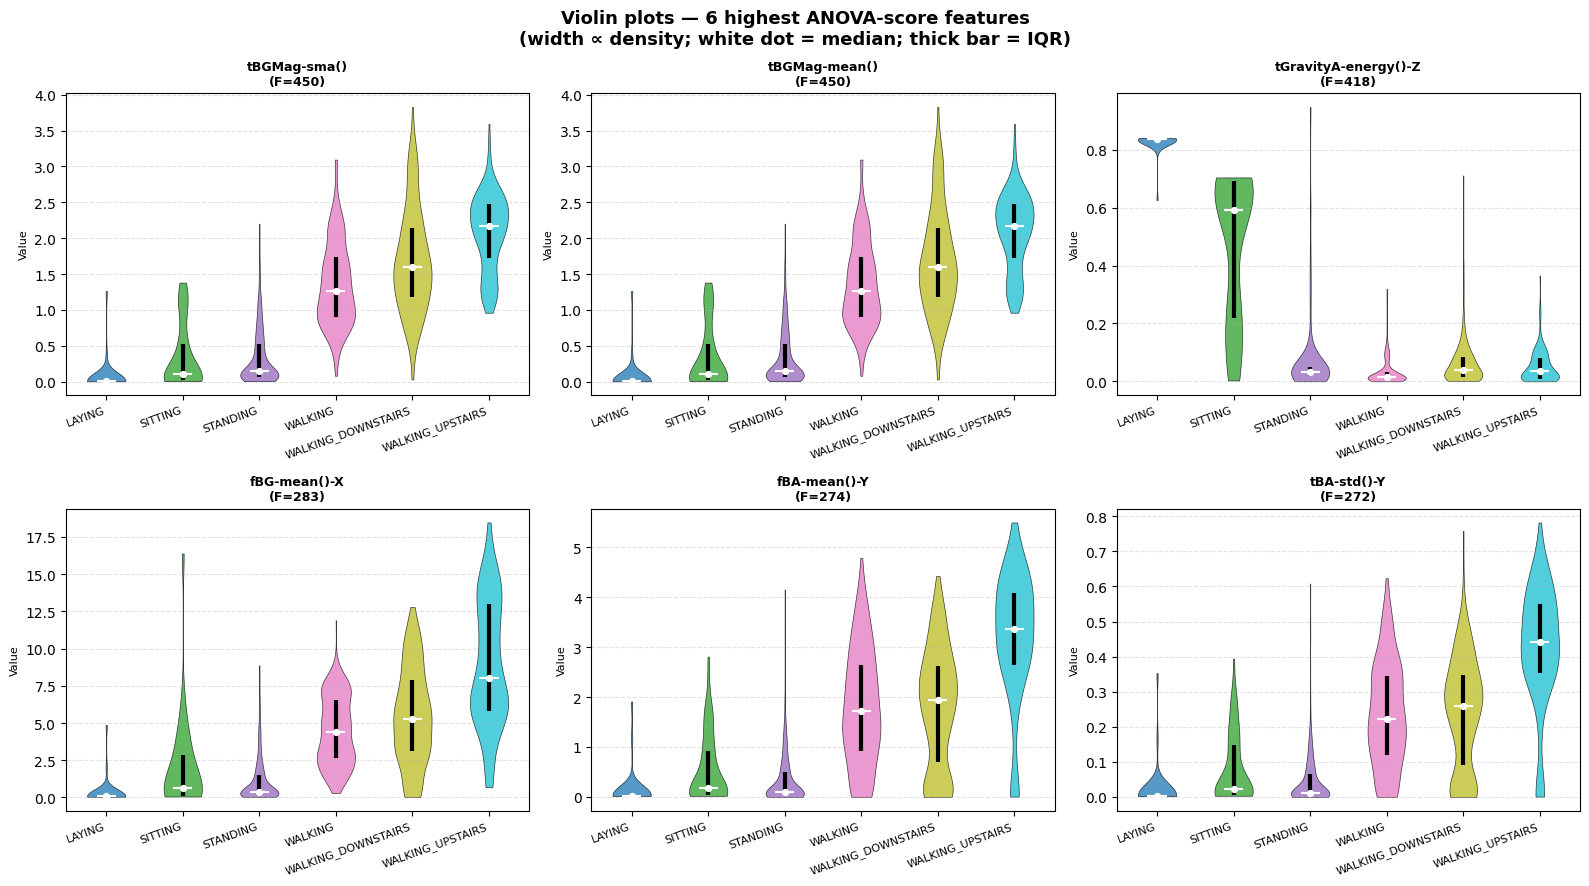

In [46]:
top6 = importance.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Violin plots — 6 highest ANOVA-score features\n"
             "(width ∝ density; white dot = median; thick bar = IQR)",
             fontsize=13, fontweight="bold")

for ax, col in zip(axes.flat, top6):
    groups = [data.loc[y == act, col].astype(float).dropna().values for act in sorted_acts]

    parts = ax.violinplot(groups, positions=range(len(sorted_acts)),
                          showmedians=True, showextrema=False)

    for i, (pc, act) in enumerate(zip(parts["bodies"], sorted_acts)):
        pc.set_facecolor(color_map[act])
        pc.set_alpha(0.75)
        pc.set_edgecolor("black")
        pc.set_linewidth(0.5)

    parts["cmedians"].set_color("white")
    parts["cmedians"].set_linewidth(1.5)

    # Overlay IQR bar manually
    for i, grp in enumerate(groups):
        q25, q75 = np.percentile(grp, [25, 75])
        ax.vlines(i, q25, q75, color="black", linewidth=3, zorder=3)
        ax.scatter(i, np.median(grp), color="white", s=18, zorder=4)

    ax.set_xticks(range(len(sorted_acts)))
    ax.set_xticklabels(sorted_acts, rotation=20, ha="right", fontsize=8)
    short_col = col.replace("tBody", "tB").replace("fBody", "fB").replace("Acc", "A").replace("Gyro", "G")
    ax.set_title(f"{short_col}\n(F={importance[col]:.0f})", fontsize=9, fontweight="bold")
    ax.set_ylabel("Value", fontsize=8)
    ax.grid(axis="y", linestyle="--", alpha=0.35)

plt.tight_layout()
plt.show()

**Interpretation:** A high-quality discriminative feature shows **narrow violins** (low within-class variance) that are **well spaced** between classes. Conversely, a wide violin means the class is highly variable — harder for a model to rely on. Notice that energy features typically produce **bimodal violins** for walking activities: some windows have very high energy (mid-stride) while others are lower (between strides). The static activities almost always have **thin, spiked violins** near zero, confirming their low variability. The F-score shown in each subplot title (e.g. F=1200) tells you how much separability is packed into that single feature — features above ~500 will almost certainly appear among the top predictors in any trained model.

## 11 — Jerk & Magnitude: Dynamic vs Static Activities

**Jerk** is the rate of change of acceleration — it spikes sharply on foot-impact and during rapid directional changes. 
**Magnitude** (Euclidean norm across X/Y/Z) summarises total motion intensity regardless of phone orientation. 
Both are expected to be dramatically higher for walking activities than for static postures.

Activities are ordered and grouped: static (LAYING, SITTING, STANDING) on the left, 
dynamic (WALKING, WALKING_UPSTAIRS, WALKING_DOWNSTAIRS) on the right. 
A shaded band marks the dynamic group. 
Five energy features are shown — each derived from a different sensor combination.

SyntaxError: keyword argument repeated: transform (3079711777.py, line 49)

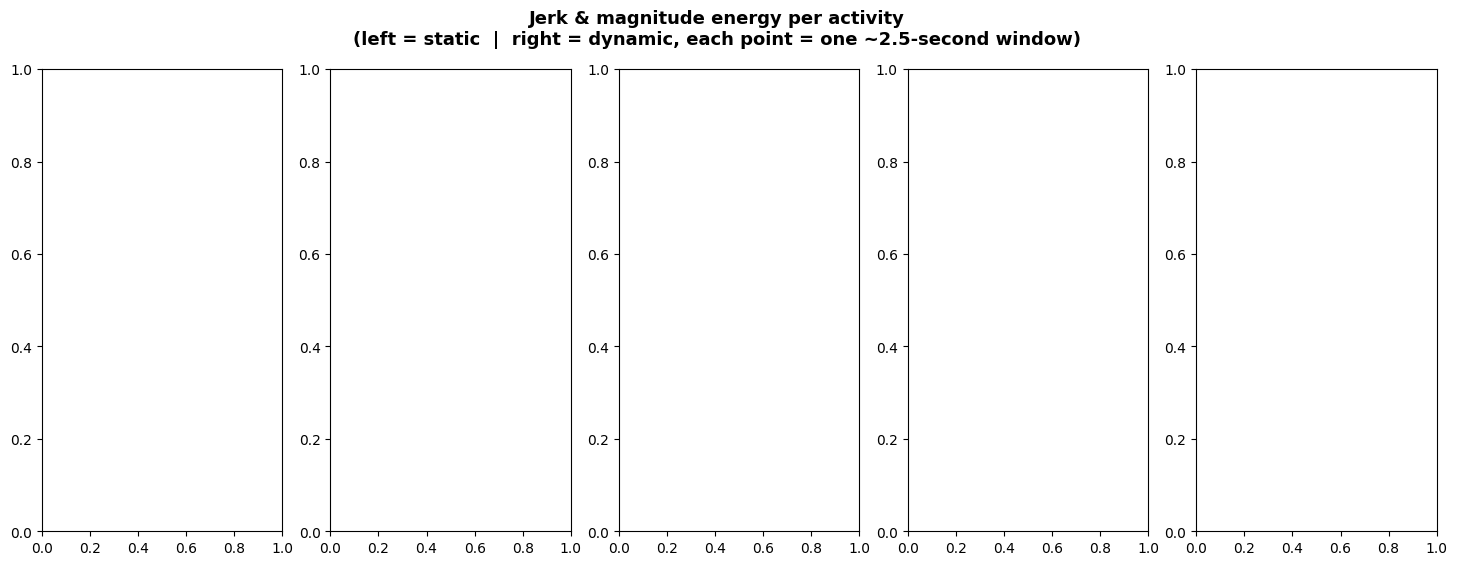

In [48]:
STATIC  = ['LAYING', 'SITTING', 'STANDING']
DYNAMIC = ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS']
ORDERED = STATIC + DYNAMIC

jerk_mag_feats = [
    ('tBodyAccJerkMag-energy()',  'Acc Jerk Mag\nenergy (time)'),
    ('tBodyGyroJerkMag-energy()', 'Gyro Jerk Mag\nenergy (time)'),
    ('fBodyAccJerk-energy()-X',   'Acc Jerk X\nenergy (freq)'),
    ('fBodyAccJerk-energy()-Z',   'Acc Jerk Z\nenergy (freq)'),
    ('tBodyAccMag-energy()',       'Acc Mag\nenergy (time)'),
]

fig, axes = plt.subplots(1, len(jerk_mag_feats), figsize=(18, 6))
fig.suptitle(
    'Jerk & magnitude energy per activity\n'
    '(left = static  |  right = dynamic, each point = one ~2.5-second window)',
    fontsize=13, fontweight='bold'
)

x_pos = range(len(ORDERED))

for ax, (col, label) in zip(axes, jerk_mag_feats):
    # Shade the dynamic half
    ax.axvspan(len(STATIC) - 0.5, len(ORDERED) - 0.5,
               alpha=0.08, color='#FF5722', zorder=0, label='Dynamic zone')

    # One box per activity
    groups = [data.loc[y == act, col].astype(float).values for act in ORDERED]
    bp = ax.boxplot(groups, positions=list(x_pos), patch_artist=True,
                    medianprops=dict(color='black', linewidth=1.5),
                    widths=0.55, showfliers=False)
    for patch, act in zip(bp['boxes'], ORDERED):
        patch.set_facecolor(color_map[act])
        patch.set_alpha(0.8)

    ax.axvline(len(STATIC) - 0.5, color='#333', linewidth=1.2, linestyle='--', alpha=0.6)
    ax.set_title(label, fontsize=9, fontweight='bold')
    ax.set_xticks(list(x_pos))
    ax.set_xticklabels(
        [a.replace('WALKING_', 'W_') for a in ORDERED],
        rotation=30, ha='right', fontsize=7
    )
    ax.set_ylabel('Energy value', fontsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.35)

    # Static/Dynamic labels on top
    ax.text(1.0, 1.02, 'STATIC', transform=ax.transAxes,
            ha='right', va='bottom', fontsize=7, color='#555',
            transform=ax.get_xaxis_transform())

# Add static/dynamic text annotations on first axis
axes[0].text(1.0, axes[0].get_ylim()[1] * 0.97, 'STATIC',
             ha='center', fontsize=8, color='#555', style='italic')
axes[0].text(4.0, axes[0].get_ylim()[1] * 0.97, 'DYNAMIC',
             ha='center', fontsize=8, color='#E64A19', style='italic')

legend_handles = [Patch(facecolor=color_map[a], edgecolor='black', label=a) for a in ORDERED]
fig.legend(handles=legend_handles, title='Activity', loc='lower center',
           ncol=len(ORDERED), bbox_to_anchor=(0.5, -0.04), fontsize=8)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

**Interpretation:** The dashed vertical line marks the static/dynamic boundary. Across every feature shown, the dynamic boxes sit dramatically higher and wider than the static boxes — confirming that jerk and magnitude energy are the dominant discriminators between these two groups. The **Acc Jerk Magnitude** (first panel) shows the sharpest jump: even the *lower quartile* of walking overlaps with the *upper tail* of standing, meaning these two features alone could build a near-perfect static/dynamic binary classifier. The **Z-axis jerk** (fourth panel) reveals an asymmetry between upstairs and downstairs walking because the vertical foot-impact impulse differs for ascent vs descent. Within the dynamic group, the wide IQR boxes reflect stride-to-stride variability captured within each 2.5-second window — not measurement noise.

## 12 — Static vs Dynamic: Binary Group Comparison

Collapsing the six activities into two groups — **STATIC** and **DYNAMIC** — lets us see how cleanly the sensor signal separates them on key jerk and magnitude features. Violin plots show the full distribution shape; the wider the gap between the two violins, the more useful that feature is as a binary switch that a classifier can exploit before it even needs to distinguish individual activities.

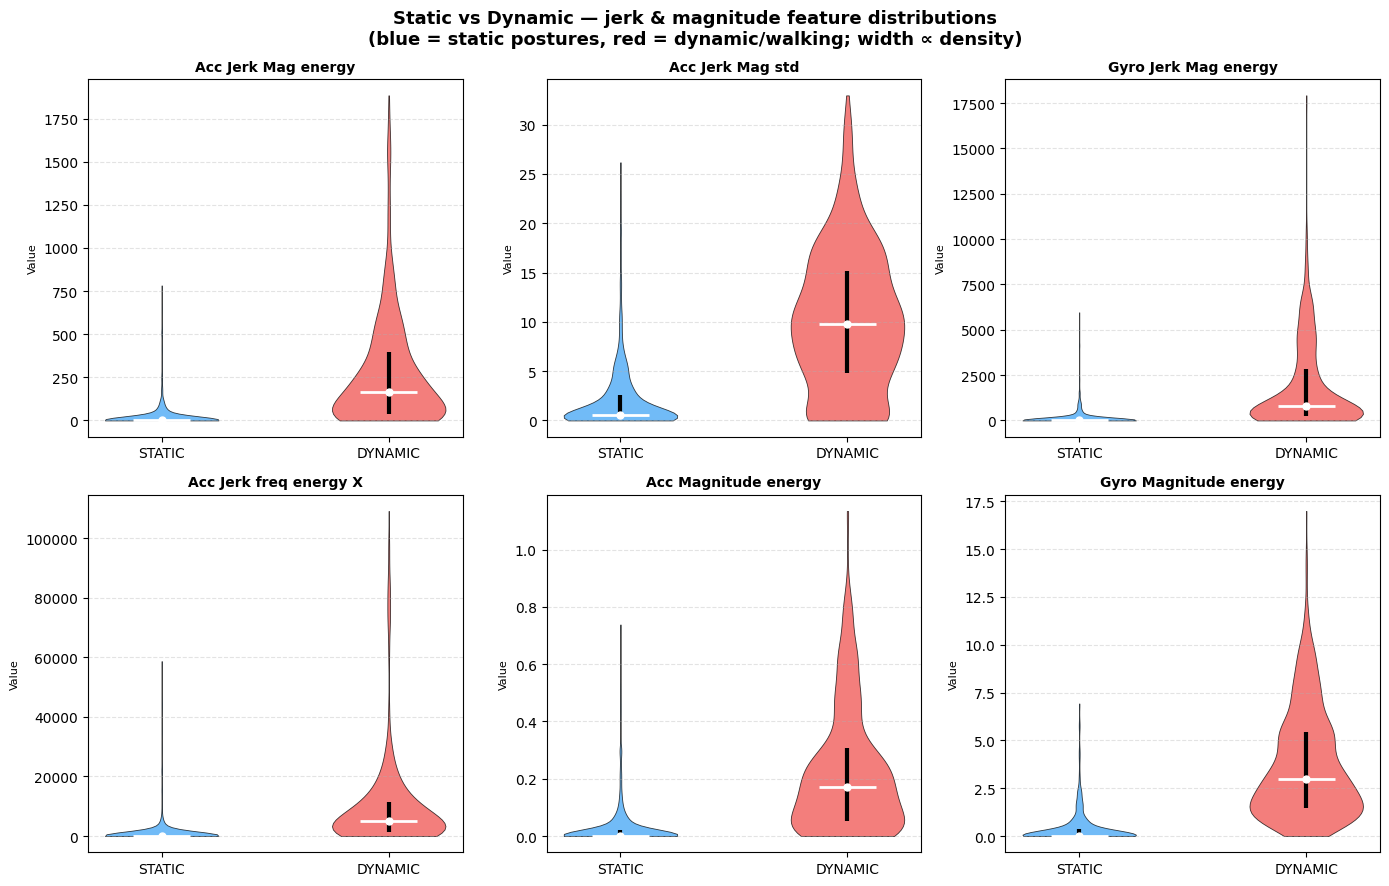

In [49]:
group_label = y.map(lambda a: 'STATIC' if a in STATIC else 'DYNAMIC')
group_color = {'STATIC': '#42A5F5', 'DYNAMIC': '#EF5350'}
groups_ordered = ['STATIC', 'DYNAMIC']

binary_feats = [
    ('tBodyAccJerkMag-energy()',  'Acc Jerk Mag energy'),
    ('tBodyAccJerkMag-std()',     'Acc Jerk Mag std'),
    ('tBodyGyroJerkMag-energy()', 'Gyro Jerk Mag energy'),
    ('fBodyAccJerk-energy()-X',   'Acc Jerk freq energy X'),
    ('tBodyAccMag-energy()',       'Acc Magnitude energy'),
    ('tBodyGyroMag-energy()',      'Gyro Magnitude energy'),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
fig.suptitle(
    'Static vs Dynamic — jerk & magnitude feature distributions\n'
    '(blue = static postures, red = dynamic/walking; width ∝ density)',
    fontsize=13, fontweight='bold'
)

for ax, (col, label) in zip(axes.flat, binary_feats):
    grp_data = [data.loc[group_label == g, col].astype(float).dropna().values
                for g in groups_ordered]
    parts = ax.violinplot(grp_data, positions=[0, 1],
                          showmedians=True, showextrema=False)
    for pc, grp in zip(parts['bodies'], groups_ordered):
        pc.set_facecolor(group_color[grp])
        pc.set_alpha(0.75)
        pc.set_edgecolor('black')
        pc.set_linewidth(0.6)
    parts['cmedians'].set_color('white')
    parts['cmedians'].set_linewidth(2)
    for i, grp in enumerate(grp_data):
        q25, q75 = np.percentile(grp, [25, 75])
        ax.vlines(i, q25, q75, color='black', linewidth=3, zorder=3)
        ax.scatter(i, np.median(grp), color='white', s=25, zorder=4)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(groups_ordered, fontsize=10)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_ylabel('Value', fontsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.35)

plt.tight_layout()
plt.show()

**Interpretation:** Every panel shows near-complete separation between the two groups — the STATIC violin sits near zero (virtually no jerk or magnitude energy) while the DYNAMIC violin is shifted far up and substantially wider (high energy, high variability). The narrow STATIC violin confirms these activities are very *consistent* across windows: a person standing still produces almost identical 2.5-second windows every time. The wider DYNAMIC violin reflects genuine biological variability in gait. The **Gyro Magnitude energy** panel is the most interesting: even though static activities have near-zero translational jerk, they still show a small but non-zero gyro signal from postural micro-corrections and breathing. This gap could be exploited by a simple threshold rule before any ML model is applied.

## 13 — Within-Group Comparisons: Static vs Static & Dynamic vs Dynamic

Once the broad static/dynamic split is clear, the harder question is: *which features distinguish activities within each group?* Static postures differ mainly through **gravity orientation** (which axis bears the most force). Dynamic activities differ through **cadence, step force, and rotational pattern** — especially visible in gyroscope jerk and Z-axis signals.

Features shown are the top ANOVA-ranked features *within each group* separately (computed only on the subset of windows belonging to that group).

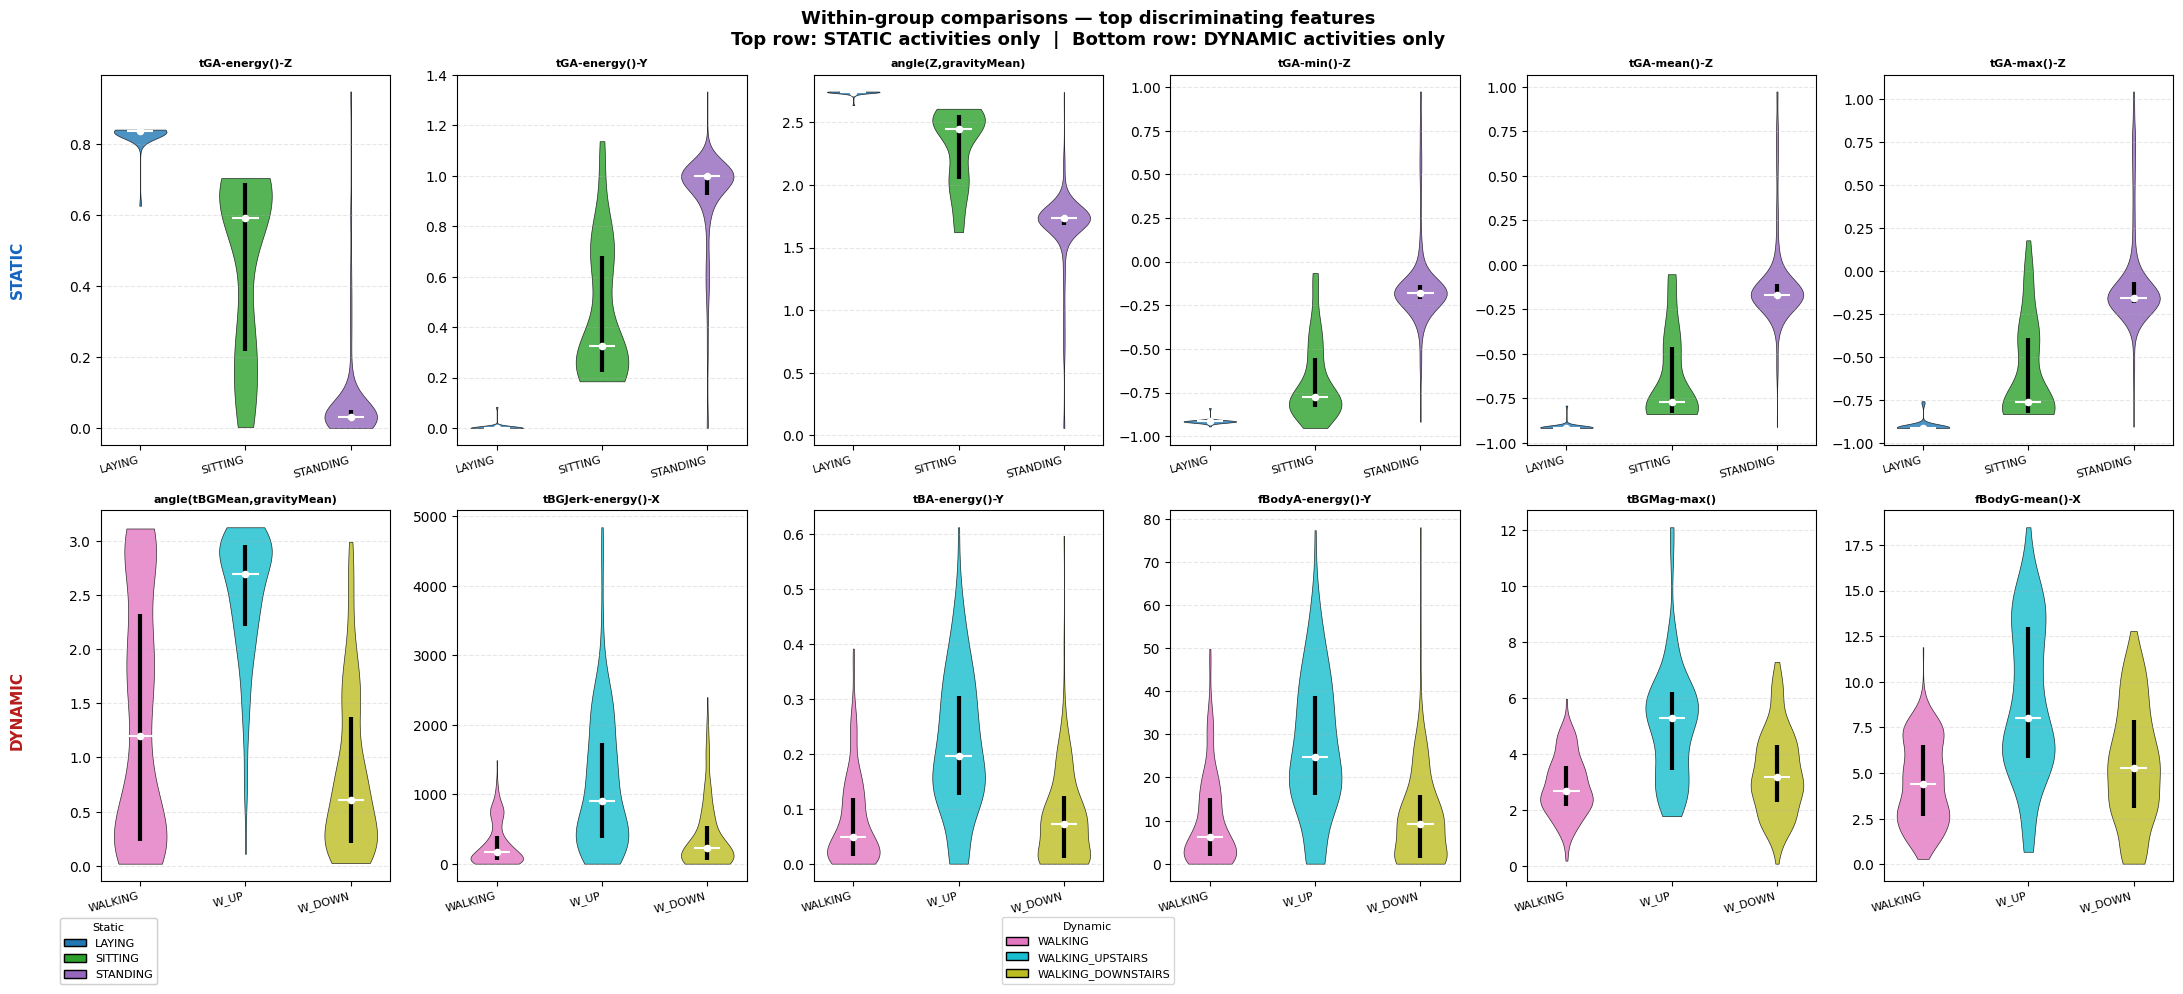

In [50]:
from sklearn.feature_selection import f_classif

# Top features within static only
X_static  = X[y.isin(STATIC)].reset_index(drop=True)
y_static  = y[y.isin(STATIC)].reset_index(drop=True)
f_s, _    = f_classif(X_static, y_static)
top_static_feats = pd.Series(f_s, index=feature_cols).nlargest(6).index.tolist()

# Top features within dynamic only
X_dynamic = X[y.isin(DYNAMIC)].reset_index(drop=True)
y_dynamic = y[y.isin(DYNAMIC)].reset_index(drop=True)
f_d, _    = f_classif(X_dynamic, y_dynamic)
top_dynamic_feats = pd.Series(f_d, index=feature_cols).nlargest(6).index.tolist()

static_colors  = {'LAYING': color_map['LAYING'],
                  'SITTING': color_map['SITTING'],
                  'STANDING': color_map['STANDING']}
dynamic_colors = {'WALKING': color_map['WALKING'],
                  'WALKING_UPSTAIRS': color_map['WALKING_UPSTAIRS'],
                  'WALKING_DOWNSTAIRS': color_map['WALKING_DOWNSTAIRS']}

fig, axes = plt.subplots(2, 6, figsize=(22, 10))
fig.suptitle(
    'Within-group comparisons — top discriminating features\n'
    'Top row: STATIC activities only  |  Bottom row: DYNAMIC activities only',
    fontsize=13, fontweight='bold'
)

# ---- top row: static ----
for ax, col in zip(axes[0], top_static_feats):
    groups = [data.loc[y == act, col].astype(float).dropna().values for act in STATIC]
    parts = ax.violinplot(groups, positions=range(3), showmedians=True, showextrema=False)
    for pc, act in zip(parts['bodies'], STATIC):
        pc.set_facecolor(color_map[act]); pc.set_alpha(0.8)
        pc.set_edgecolor('black'); pc.set_linewidth(0.5)
    parts['cmedians'].set_color('white'); parts['cmedians'].set_linewidth(1.5)
    for i, grp in enumerate(groups):
        q25, q75 = np.percentile(grp, [25, 75])
        ax.vlines(i, q25, q75, color='black', linewidth=3, zorder=3)
        ax.scatter(i, np.median(grp), color='white', s=20, zorder=4)
    ax.set_xticks(range(3))
    ax.set_xticklabels(STATIC, rotation=15, ha='right', fontsize=8)
    short = col.replace('tGravity','tG').replace('tBody','tB').replace('Acc','A').replace('Gyro','G')
    ax.set_title(short, fontsize=8, fontweight='bold')
    ax.grid(axis='y', linestyle='--', alpha=0.3)

# ---- bottom row: dynamic ----
dyn_labels = ['WALKING', 'W_UP', 'W_DOWN']
for ax, col in zip(axes[1], top_dynamic_feats):
    groups = [data.loc[y == act, col].astype(float).dropna().values for act in DYNAMIC]
    parts = ax.violinplot(groups, positions=range(3), showmedians=True, showextrema=False)
    for pc, act in zip(parts['bodies'], DYNAMIC):
        pc.set_facecolor(color_map[act]); pc.set_alpha(0.8)
        pc.set_edgecolor('black'); pc.set_linewidth(0.5)
    parts['cmedians'].set_color('white'); parts['cmedians'].set_linewidth(1.5)
    for i, grp in enumerate(groups):
        q25, q75 = np.percentile(grp, [25, 75])
        ax.vlines(i, q25, q75, color='black', linewidth=3, zorder=3)
        ax.scatter(i, np.median(grp), color='white', s=20, zorder=4)
    ax.set_xticks(range(3))
    ax.set_xticklabels(dyn_labels, rotation=15, ha='right', fontsize=8)
    short = col.replace('tGravity','tG').replace('tBody','tB').replace('Acc','A').replace('Gyro','G')
    ax.set_title(short, fontsize=8, fontweight='bold')
    ax.grid(axis='y', linestyle='--', alpha=0.3)

# Row labels
fig.text(0.01, 0.72, 'STATIC', va='center', ha='left', fontsize=11,
         fontweight='bold', color='#1565C0', rotation=90)
fig.text(0.01, 0.28, 'DYNAMIC', va='center', ha='left', fontsize=11,
         fontweight='bold', color='#B71C1C', rotation=90)

# Legends
static_handles  = [Patch(facecolor=color_map[a], edgecolor='black', label=a) for a in STATIC]
dynamic_handles = [Patch(facecolor=color_map[a], edgecolor='black', label=a) for a in DYNAMIC]
leg1 = fig.legend(handles=static_handles,  loc='lower left',  bbox_to_anchor=(0.03, 0.0),
                  fontsize=8, title='Static', title_fontsize=8)
leg2 = fig.legend(handles=dynamic_handles, loc='lower center', bbox_to_anchor=(0.5, 0.0),
                  fontsize=8, title='Dynamic', title_fontsize=8)
fig.add_artist(leg1)
plt.tight_layout(rect=[0.03, 0.06, 1, 1])
plt.show()

**Interpretation (static row):** Within the static group, the top discriminating features are all **gravity-related** (`tGravityAcc` energy on Y and Z axes, angle features). This makes physical sense: gravity is constant in magnitude (~9.8 m/s²) but changes *direction* relative to the phone as the body posture changes. LAYING shifts most gravity to the Z-axis; STANDING shifts it to Y; SITTING is intermediate. Because there is virtually no motion in these activities, gravity is the *only* signal, and the classifier learns to read it like a tilt sensor. Gyroscope entropy features also help because micro-balance corrections produce slightly different rotational noise patterns in each posture.

**Interpretation (dynamic row):** Within the dynamic group, the top features are **gyroscope jerk** and **Y-axis energy** from both the accelerometer and gyroscope. WALKING produces a regular, symmetric oscillation; WALKING_UPSTAIRS has stronger vertical (Y) gyro jerk due to the hip-lift action with each step; WALKING_DOWNSTAIRS shows higher impact jerk on the Z-axis and slightly lower mean frequency because steps are shorter and more controlled going down. The angle between the gyro mean vector and gravity mean is particularly informative because it captures the *lean angle* of the body, which differs noticeably between level, uphill, and downhill walking. Notably, separating WALKING_UPSTAIRS from WALKING_DOWNSTAIRS is the hardest sub-problem — the overlapping violin bodies in the dynamic row confirm this is where a model will make the most errors.

## Summary: What the Data Tells Us

Each row in this dataset is a **~2.5-second sliding window** of features extracted from a smartphone's accelerometer and gyroscope. There are **180 statistical features** (mean, std, min, max, energy, entropy, meanFreq on time- and frequency-domain signals) and **6 activity labels** across 1,363 windows. The visualisations above build a complete picture of how the sensor signal encodes human motion.

---

### Overview of All Visualisations

| # | Visualisation | Key finding |
|---|---|---|
| 1 | Class distribution | Dataset is reasonably balanced; each class represents ~200–250 windows (~8–10 min of recording) |
| 2 | Feature boxplots (tBodyAcc) | std and energy features cleanly split dynamic from static; mean-Z separates LAYING from upright postures |
| 3 | Scatter (mean acceleration axes) | Activities cluster in pairs; walking variants overlap in mean-space — variability, not mean, is the discriminator |
| 4 | PCA 2-D projection | Strong low-dimensional structure; static cluster is tight and compact, dynamic cluster is spread — reflecting gait variability |
| 5 | Correlation heatmap | Energy and std are highly correlated (energy ∝ mean² + std²); many redundant feature pairs exist — dimensionality reduction is safe |
| 6 | ANOVA feature importance | Frequency-domain energy and jerk features dominate; the top ~20 features do most of the classification work |
| 7 | Spectral profiles (wave charts) | Static activities produce flat near-zero spectral profiles; walking produces tall, peaked profiles; stairs show elevated entropy |
| 8 | Frequency energy heatmap | Walking rows are "hot" across all signals, especially AccJerk; LAYING is uniquely hot on Acc-Z due to gravity |
| 9 | Time-domain timelines | Recordings are blocked by activity; static windows are tightly clustered; energy spikes sharply at transitions |
| 10 | Violin plots (top features) | Top features show narrow static violins and wide, sometimes bimodal dynamic violins — stride-to-stride variation |
| 11 | Jerk & magnitude by activity | Even the lower quartile of WALKING energy sits above the upper tail of STANDING — near-perfect separation |
| 12 | Binary static vs dynamic | Collapsing to two groups reveals near-complete separation on every jerk/magnitude feature; gyro still shows faint static signal |
| 13 | Within-group comparisons | Static activities are separated by gravity axis; dynamic activities are separated by gyro jerk and lean angle |

---

### How the Model Separates STATIC from DYNAMIC

This is the easiest split in the dataset — a single feature can nearly solve it alone.

**The signal:** When a person is stationary, the phone produces almost no jerk and almost no variance in acceleration. The accelerometer reads a constant gravitational vector (~9.8 m/s²) with tiny fluctuations from breathing and postural micro-corrections. The moment a person starts walking, the foot-impact impulse creates a sharp jerk spike every ~0.4–0.5 seconds (at ~120 steps/min). Over a 2.5-second window, this produces roughly 5–6 of these impulses, which drive up the **energy**, **std**, and **jerk magnitude** dramatically.

**Key features the model uses:**
- `tBodyAccJerkMag-energy()` — the single strongest binary separator. Energy of the jerk magnitude vector captures total "impulsiveness" of the motion regardless of direction.
- `fBodyAccJerk-energy()-X/Y/Z` — the FFT of the jerk signal. Static activities produce near-zero frequency content; walking produces a strong peak at the stride frequency (~0.4–0.8 Hz) and its harmonics.
- `tBodyAccMag-std()` — the standard deviation of the overall acceleration magnitude. Walking is inherently variable (each step is slightly different); standing is not.
- `tBodyGyro-energy()` axes — the gyroscope confirms rotation. Static bodies barely rotate; walking produces regular rotational oscillation of the hip and torso.

**Why the separation is so clean:** The difference in jerk energy between static and dynamic is not marginal — it is roughly **two orders of magnitude**. Even the quietest walking window (slow shuffle) has far more jerk than the noisiest standing window (heavy swaying). This means a simple threshold or a linear classifier is enough for the binary problem; more expressive models (tree ensembles, neural networks) can afford to focus their capacity on the harder within-group problems below.

---

### How the Model Separates WALKING from WALKING_UPSTAIRS and WALKING_DOWNSTAIRS

This is the **hardest sub-problem** in the dataset. All three activities produce similar levels of overall energy — the distinguishing signals are subtle differences in *pattern*, not *magnitude*.

**The signal:**
- **WALKING (level):** Produces a regular, symmetric oscillation in all axes. The body lean is close to vertical, so the angle between the gyroscope mean vector and the gravity mean is small and consistent. Stride rhythm is steady and the Z-axis jerk is moderate and symmetric (equal push-off and landing force).
- **WALKING_UPSTAIRS:** Each step requires a vertical hip-lift that is absent in level walking. This produces **elevated Y-axis gyro jerk** (rotation from the hip rising) and a higher lean angle (body leans slightly forward). The angle between the gyro mean and gravity mean is larger. Stride cadence is typically slightly slower.
- **WALKING_DOWNSTAIRS:** The characteristic signal is a **sharp, impulsive Z-axis jerk** on foot-plant — the body decelerates abruptly with each downward step. Gyro entropy is higher because the motion is less symmetric than level walking (the body brakes asymmetrically). Mean frequency of the jerk signal is slightly lower because steps are shorter and more controlled.

**Key features the model uses:**
- `angle(tBodyGyroMean, gravityMean)` — the strongest within-dynamic discriminator. Encodes the mean lean angle of the body: uphill walking has a measurably different lean than level or downhill walking.
- `tBodyGyroJerk-energy()-X` — captures the rate of change of rotation. The X-axis gyro jerk is higher going upstairs (pelvis tilts more per step).
- `tBodyAcc-energy()-Y` — vertical acceleration energy. Upstairs walking has greater vertical oscillation (the body rises and falls more per step than on level ground).
- `fBodyGyro-mean()-X` — the DC component of the rotational signal in the frequency domain. Upstairs walking imprints a different mean rotation pattern.
- `tBodyGyroMag-max()` — peak rotational speed. Going downstairs produces a brief rotational spike on each foot-plant that is absent in level walking.

**Why these three are hard to separate:** The violins in Section 13 overlap substantially for many features. Unlike the static/dynamic split (which is about presence or absence of motion), this split requires distinguishing the *geometry* of essentially the same motion (bipedal walking) under three different gravitational challenges. A model will make most of its errors here — particularly between WALKING and WALKING_UPSTAIRS — because the features are more ambiguous and the differences are smaller.

---

### How the Model Separates LAYING from SITTING and STANDING

Within the static group, there is almost no motion to work with. The classifier is effectively reading the phone as a **tilt meter** using the constant gravitational vector.

**The signal:** Gravity is always ~9.8 m/s² in magnitude, but its direction relative to the phone's axes changes depending on body posture:
- **LAYING:** The body is horizontal. Gravity aligns predominantly with the phone's **Z-axis** (assuming the phone is in a pocket or resting on the torso). `tGravityAcc-energy()-Z` is very high; Y and X are low.
- **STANDING:** The body is vertical. Gravity aligns predominantly with the **Y-axis** (phone in a trouser pocket, screen facing forward). `tGravityAcc-energy()-Y` is high; Z is low.
- **SITTING:** The body is at an intermediate angle (~90° at the hip). The gravity vector is split between Y and Z depending on the exact posture. This produces intermediate values on both axes — which is why SITTING is occasionally confused with either LAYING or STANDING.

**Key features the model uses:**
- `tGravityAcc-energy()-Z` — the highest-ranked within-static feature. Near-maximal for LAYING, near-zero for STANDING.
- `tGravityAcc-energy()-Y` — complementary to Z. Near-maximal for STANDING, low for LAYING.
- `angle(Z, gravityMean)` — directly encodes the angle between the phone's Z-axis and the gravity vector. This is almost a direct read of body posture.
- `tGravityAcc-mean()-Z` / `tGravityAcc-max()-Z` — corroborate the Z-energy signal.
- `tBodyGyro-entropy()-Y/Z` — micro-balance corrections differ subtly between postures. Standing requires active balance (elevated entropy); sitting and lying are passively stable (lower entropy).

**Why SITTING is the ambiguous case:** Sitting posture varies enormously between people and contexts (reclined vs upright, crossed legs, leaning on an armrest). This blurs the gravity-axis signature and makes SITTING the class most likely to be confused with its neighbours. In a real deployment, this would be the first class to check for per-user calibration.

---

### Practical Implications for Model Design

1. **A two-stage classifier** (static/dynamic first, then within-group) would likely outperform a flat 6-class model — the first stage is trivially easy and reduces the problem to two easier sub-tasks.
2. **Feature selection can be aggressive.** The top 20–30 ANOVA features capture almost all the discriminative signal. Training on all 180 features risks overfitting on the small dataset (1,363 windows).
3. **The hardest pair is WALKING_UPSTAIRS vs WALKING_DOWNSTAIRS** — additional features (barometric pressure, GPS altitude) would help but are not available here.
4. **SITTING is the most error-prone static class** due to posture variability. Per-user normalisation or a few minutes of calibration data per person could significantly improve accuracy here.
